<a href="https://colab.research.google.com/github/Sargam2808/DEEP_LEARNING_LAB/blob/main/DL_lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implementation of a simple neural network to classify both linearly separable and non-linearly separable datas

Importing Libraries

In [19]:
# Numerical computations
import numpy as np

# For plotting graphs
import matplotlib.pyplot as plt

# For creating datasets
from sklearn.datasets import make_classification, make_moons

# For splitting data
from sklearn.model_selection import train_test_split


Creating Linear Dataset

In [20]:
# Creating a linearly separable dataset
X_linear, y_linear = make_classification(
    n_samples=500,        # total data points
    n_features=2,         # two features (easy to visualize)
    n_redundant=0,        # no useless features
    n_clusters_per_class=1,
    class_sep=2.5,
    random_state=1
)

# Converting labels into column shape
y_linear = y_linear.reshape(-1, 1)


Visualizing Linear Dataset

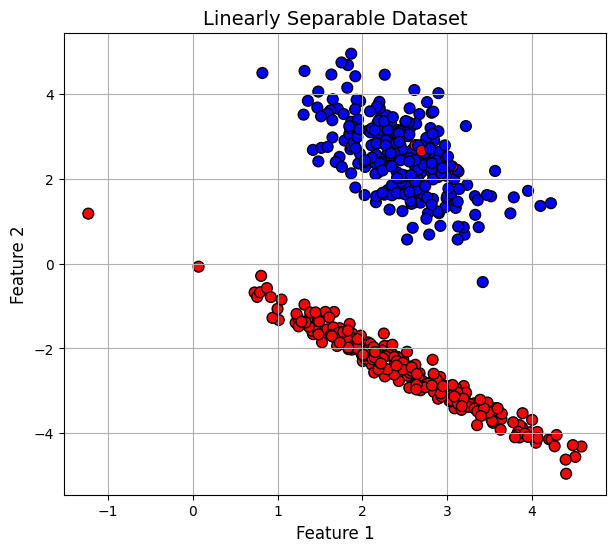

In [21]:
plt.figure(figsize=(7, 6))
plt.scatter(
    X_linear[:, 0],
    X_linear[:, 1],
    c=y_linear.ravel(),
    cmap='bwr',
    s=60,
    edgecolors='black'
)
plt.xlabel("Feature 1", fontsize=12)
plt.ylabel("Feature 2", fontsize=12)
plt.title("Linearly Separable Dataset", fontsize=14)
plt.grid(True)
plt.show()


Splitting Linear Data

In [22]:
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_linear, y_linear,
    test_size=0.2,
    random_state=1)



Sigmoid Function(output layer)

In [23]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


Training a Simple Perceptron

In [24]:
def train_perceptron(X, y, learning_rate=0.1, epochs=1000):
    samples, features = X.shape

    # Initializing weights and bias
    weights = np.random.randn(features, 1)
    bias = 0

    for epoch in range(epochs):

        # Forward pass
        z = np.dot(X, weights) + bias
        prediction = sigmoid(z)

        # Error
        error = prediction - y

        # Gradient calculation
        dW = np.dot(X.T, error) / samples
        dB = np.mean(error)

        # Update weights
        weights -= learning_rate * dW
        bias -= learning_rate * dB

    return weights, bias


Testing Perceptron

In [25]:
weights, bias = train_perceptron(X_train_l, y_train_l)

#predictions
z_test = np.dot(X_test_l, weights) + bias
predictions = sigmoid(z_test)
predicted_classes = (predictions > 0.5).astype(int)

# Accuracy
accuracy_linear = np.mean(predicted_classes == y_test_l)
print("Perceptron Accuracy (Linear Data):", accuracy_linear)


Perceptron Accuracy (Linear Data): 0.98


NON-LINEAR DATA (MOON SHAPE)

In [26]:
X_nonlinear, y_nonlinear = make_moons(
    n_samples=500,
    noise=0.2,
    random_state=1)

y_nonlinear = y_nonlinear.reshape(-1, 1)


Visualizing Non-linear Dataset

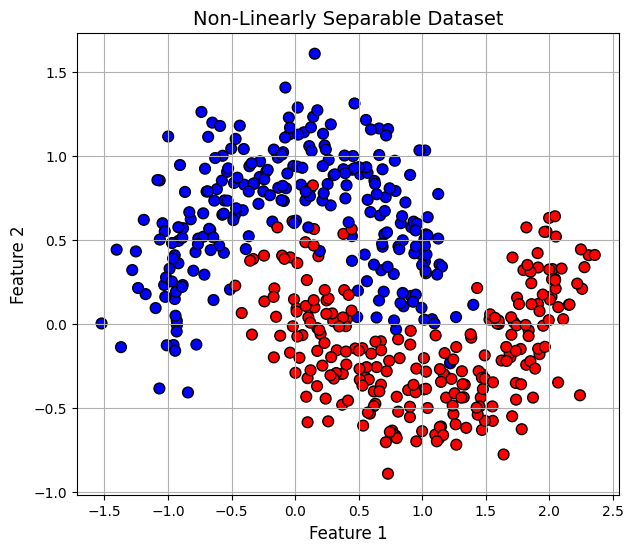

In [27]:
plt.figure(figsize=(7, 6))
plt.scatter(
    X_nonlinear[:, 0],
    X_nonlinear[:, 1],
    c=y_nonlinear.ravel(),
    cmap='bwr',
    s=60,
    edgecolors='black')

plt.xlabel("Feature 1", fontsize=12)
plt.ylabel("Feature 2", fontsize=12)
plt.title("Non-Linearly Separable Dataset", fontsize=14)
plt.grid(True)
plt.show()


ReLU Function (Hidden Layer)

In [28]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return z > 0


In [29]:
# Train perceptron on non-linear (moon) data
weights_nl, bias_nl = train_perceptron(X_train_nl, y_train_nl)

# Test accuracy
z_test = np.dot(X_test_nl, weights_nl) + bias_nl
predictions = sigmoid(z_test)
predicted_classes = (predictions > 0.5).astype(int)

print("Perceptron Accuracy on Non-Linear Data:",
      np.mean(predicted_classes == y_test_nl))


Perceptron Accuracy on Non-Linear Data: 0.88


In [30]:
def plot_decision_boundary(X, y, weights, bias, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    z = np.dot(grid, weights) + bias
    probs = sigmoid(z)
    predictions = (probs > 0.5).astype(int)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, predictions.reshape(xx.shape),
                 alpha=0.3, cmap='bwr')

    plt.scatter(X[:, 0], X[:, 1],
                c=y.ravel(), cmap='bwr',
                edgecolors='black', s=60)

    plt.title(title, fontsize=14)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.show()


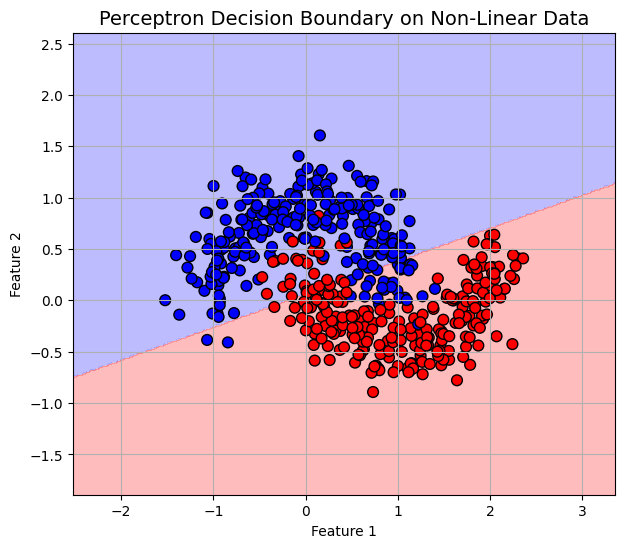

In [31]:
plot_decision_boundary(
    X_nonlinear,
    y_nonlinear,
    weights_nl,
    bias_nl,
    title="Perceptron Decision Boundary on Non-Linear Data"
)


Training multi-layer Neural Network

In [32]:
def train_neural_network(X, y, hidden_neurons=10, lr=0.1, epochs=5000):

    samples, features = X.shape

    # Initializing weights and biases
    W1 = np.random.randn(features, hidden_neurons)
    b1 = np.zeros((1, hidden_neurons))

    W2 = np.random.randn(hidden_neurons, 1)
    b2 = np.zeros((1, 1))

    for epoch in range(epochs):

        # forward pass
        Z1 = np.dot(X, W1) + b1
        A1 = relu(Z1)

        Z2 = np.dot(A1, W2) + b2
        output = sigmoid(Z2)

        # Backward pass
        error_output = output - y

        dW2 = np.dot(A1.T, error_output) / samples
        db2 = np.mean(error_output, axis=0, keepdims=True)

        error_hidden = np.dot(error_output, W2.T) * relu_derivative(Z1)

        dW1 = np.dot(X.T, error_hidden) / samples
        db1 = np.mean(error_hidden, axis=0, keepdims=True)

        # Updating parameters
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return W1, b1, W2, b2


In [35]:
def plot_nn_boundary(X, y, W1, b1, W2, b2):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    Z1 = np.dot(grid, W1) + b1
    A1 = relu(Z1)
    Z2 = np.dot(A1, W2) + b2
    probs = sigmoid(Z2)

    predictions = (probs > 0.5).astype(int)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, predictions.reshape(xx.shape),
                 alpha=0.3, cmap='bwr')

    plt.scatter(X[:, 0], X[:, 1],
                c=y.ravel(), cmap='bwr',
                edgecolors='black', s=60)

    plt.title("Neural Network Decision Boundary (Non-Linear Data)", fontsize=14)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.show()


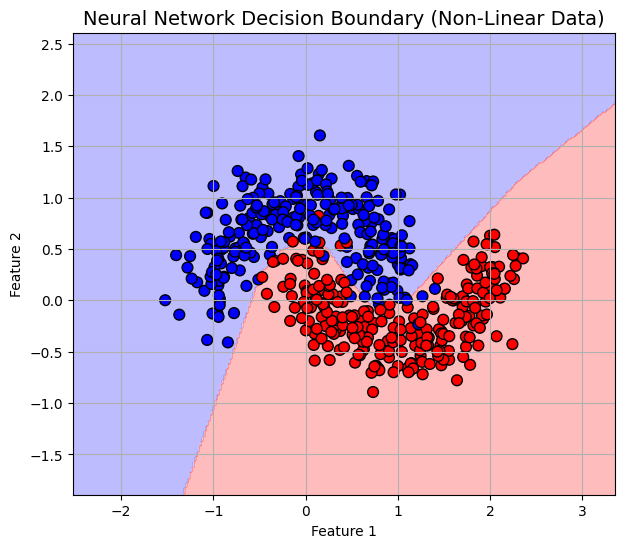

In [37]:
plot_nn_boundary(X_nonlinear, y_nonlinear, W1, b1, W2, b2)


Accuracy of non-linear data

In [36]:
Z1 = np.dot(X_test_nl, W1) + b1
A1 = relu(Z1)
Z2 = np.dot(A1, W2) + b2
probs = sigmoid(Z2)

predicted_classes = (probs > 0.5).astype(int)

accuracy_nonlinear = np.mean(predicted_classes == y_test_nl)
print("Neural Network Accuracy (Non-Linear Data):", accuracy_nonlinear)


Neural Network Accuracy (Non-Linear Data): 0.96
